# Deep Learning for Breast Cancer Detection

## Notebook Setup

Imports libraries such as TensorFlow/Keras, pandas, and other evaluation utilities. A fixed seed is set for reproducibility.

In [14]:
# Library imports
import random
import tensorflow as tf
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models
from PIL import Image
from tqdm import tqdm
import keras_tuner as kt

# Fixed seed set for reproducbility
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Confirms GPU runtime is active for Google Colab
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Connects to Google Drive, where the CBIS-DDSM JPEG dataset is located. The root, csv, and jpeg directory paths are defined here.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

ROOT = Path('/content/drive/MyDrive/CBIS-DDSM-JPEG')
CSV_DIR = ROOT / 'csv'
JPEG_DIR = ROOT / 'jpeg'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset Preparation

Mass/calcification train and test CSVs are loaded and merged into one table. A binary label is created with malignant=1 and benign=0. A join key (study_uid) is also created from the image file path so that the table can be later linked to the image files.

In [16]:
def load_cases(name, split):
    df = pd.read_csv(CSV_DIR / name)
    df.columns = df.columns.str.strip().str.replace(' ', '_')
    df['split'] = split
    return df

cases = pd.concat([
    load_cases('mass_case_description_train_set.csv', 'train'),
    load_cases('calc_case_description_train_set.csv', 'train'),
    load_cases('mass_case_description_test_set.csv', 'test'),
    load_cases('calc_case_description_test_set.csv', 'test'),
], ignore_index=True)

# Binary label: malignant=1, both benign categories=0
cases['label'] = (cases['pathology'] == 'MALIGNANT').astype(int)

# Join key: the descriptive PatientID-style identifier, taken from the leading folder of image_file_path
cases['study_uid'] = cases['image_file_path'].str.split('/').str[0]

print("Total abnormality-level rows:", len(cases))
print("\nBy split:")
print(cases['split'].value_counts())
print("\nLabel balance per split:")
print(cases.groupby('split')['label'].mean())

Total abnormality-level rows: 3568

By split:
split
train    2864
test      704
Name: count, dtype: int64

Label balance per split:
split
test     0.392045
train    0.412360
Name: label, dtype: float64


dicom_info.csv catalogues every image file in the dataset. The file is loaded and then split into mammograms, pre-cropped lesion patches, and ROI masks based on the SeriesDescription field.

In [17]:
dicom_info = pd.read_csv(CSV_DIR / 'dicom_info.csv')

print("SeriesDescription counts:")
print(dicom_info['SeriesDescription'].value_counts())

# Split image types
full = dicom_info[dicom_info['SeriesDescription'] == 'full mammogram images'].copy()
crop = dicom_info[dicom_info['SeriesDescription'] == 'cropped images'].copy()
mask = dicom_info[dicom_info['SeriesDescription'] == 'ROI mask images'].copy()

for df_ in (full, crop, mask):
    df_['image_path'] = df_['image_path'].str.replace(
        'CBIS-DDSM/jpeg', str(JPEG_DIR), regex=False
    )

print(f"\nFull mammograms: {len(full)}")
print(f"Cropped patches: {len(crop)}")
print(f"ROI masks: {len(mask)}")

SeriesDescription counts:
SeriesDescription
cropped images           3567
ROI mask images          3247
full mammogram images    2857
Name: count, dtype: int64

Full mammograms: 2857
Cropped patches: 3567
ROI masks: 3247


Each cropped image and mask is linked to its parent full mammogram by stripping the trailing abnormality index on the image. A check is done for any cropped images with no matching masks or any duplicate entries here.

In [18]:
def parent_id(pid):
    return re.sub(r'_\d+$', '', str(pid))

full['study_uid'] = full['PatientID']
crop['study_uid'] = crop['PatientID']        # abnormality-level id (has suffix)
mask['study_uid'] = mask['PatientID']        # same abnormality-level id
crop['parent_uid'] = crop['PatientID'].apply(parent_id)
mask['parent_uid'] = mask['PatientID'].apply(parent_id)

# Sanity check: every cropped patch should have exactly one matching mask,
# sharing the same study_uid (not just the same parent)
crop_ids = set(crop['study_uid'])
mask_ids = set(mask['study_uid'])
print("Cropped patches with no matching mask:", len(crop_ids - mask_ids))
print("Masks with no matching cropped patch:", len(mask_ids - crop_ids))

dupes_crop = crop[crop.duplicated('study_uid', keep=False)]
dupes_mask = mask[mask.duplicated('study_uid', keep=False)]
if len(dupes_crop):
    print(f"WARNING: {len(dupes_crop)} duplicate cropped-image entries share a study_uid")
    print(dupes_crop[['study_uid', 'image_path']].to_string())
if len(dupes_mask):
    print(f"WARNING: {len(dupes_mask)} duplicate ROI-mask entries share a study_uid")
    print(dupes_mask[['study_uid', 'image_path']].to_string())

Cropped patches with no matching mask: 320
Masks with no matching cropped patch: 0


Build a separate join key for each image type as the current CSV is reusing a single one.

In [19]:
cases['study_uid'] = cases['image_file_path'].str.split('/').str[0]
cases['crop_study_uid'] = cases['cropped_image_file_path'].str.split('/').str[0]
cases['mask_study_uid'] = cases['ROI_mask_file_path'].str.split('/').str[0]

print(cases[['study_uid', 'crop_study_uid', 'mask_study_uid']].head(5).to_string())

                         study_uid                     crop_study_uid                     mask_study_uid
0    Mass-Training_P_00001_LEFT_CC    Mass-Training_P_00001_LEFT_CC_1    Mass-Training_P_00001_LEFT_CC_1
1   Mass-Training_P_00001_LEFT_MLO   Mass-Training_P_00001_LEFT_MLO_1   Mass-Training_P_00001_LEFT_MLO_1
2    Mass-Training_P_00004_LEFT_CC    Mass-Training_P_00004_LEFT_CC_1    Mass-Training_P_00004_LEFT_CC_1
3   Mass-Training_P_00004_LEFT_MLO   Mass-Training_P_00004_LEFT_MLO_1   Mass-Training_P_00004_LEFT_MLO_1
4  Mass-Training_P_00004_RIGHT_MLO  Mass-Training_P_00004_RIGHT_MLO_1  Mass-Training_P_00004_RIGHT_MLO_1


### Creating manifests for each image type

The full-mammogram manifest is created by joining the case labels/splits to the actual full-mammogram file paths, producing one row per unique image with its label and official train/test split.

In [20]:
full_manifest = (
    cases[['study_uid', 'label', 'split']].drop_duplicates()
    .merge(full[['study_uid', 'image_path']], on='study_uid', how='inner')
    .drop_duplicates(subset='image_path')
    .dropna()
)

print("Full mammogram manifest rows:", len(full_manifest))
print("\nBy split:")
print(full_manifest['split'].value_counts())
print("\nLabel balance per split:")
print(full_manifest.groupby('split')['label'].mean())

print("\nFile existence check (first 5):")
for p in full_manifest['image_path'].head(5):
    print(Path(p).exists(), p)

Full mammogram manifest rows: 2857

By split:
split
train    2458
test      399
Name: count, dtype: int64

Label balance per split:
split
test     0.411028
train    0.449146
Name: label, dtype: float64

File existence check (first 5):
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834/1-207.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540/1-250.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162/1-067.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.410524754913057908920631336070876889890/1-056.jpg


The cropped-patch manifest follows the same join pattern as above to create the benign/malignant training examples for the patch classifier later.

In [21]:
crop_manifest = (
    cases[['crop_study_uid', 'label', 'split']]
    .drop_duplicates()
    .rename(columns={'crop_study_uid': 'study_uid'})
    .merge(crop[['study_uid', 'parent_uid', 'image_path']], on='study_uid', how='inner')
    .dropna()
)

print("Cropped patch manifest rows:", len(crop_manifest))
print("\nBy split:")
print(crop_manifest['split'].value_counts())
print("\nLabel balance per split:")
print(crop_manifest.groupby('split')['label'].mean())

print("\nFile existence check (first 5):")
for p in crop_manifest['image_path'].head(5):
    print(Path(p).exists(), p)

Cropped patch manifest rows: 3567

By split:
split
train    2863
test      704
Name: count, dtype: int64

Label balance per split:
split
test     0.392045
train    0.412504
Name: label, dtype: float64

File existence check (first 5):
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/2-249.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.227955274711225756835838775062793186053/1-289.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/2-295.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.115134232113001553100559896703407510515/2-244.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.12857366312625701203276284233604184846/1-182.jpg


The mask manifest is created by linking each ROI mask to its split/label and to its parent full mammogram's path. This is used for identifying where lesions are located when sampling background patches.

In [22]:
mask_manifest = (
    cases[['mask_study_uid', 'parent_uid' if 'parent_uid' in cases.columns else 'mask_study_uid']]
)

mask_manifest = (
    cases[['mask_study_uid', 'label', 'split']]
    .drop_duplicates()
    .rename(columns={'mask_study_uid': 'study_uid'})
    .merge(mask[['study_uid', 'parent_uid', 'image_path']], on='study_uid', how='inner')
    .rename(columns={'image_path': 'mask_path'})
    .merge(full_manifest[['study_uid', 'image_path']].rename(
        columns={'study_uid': 'parent_uid', 'image_path': 'parent_image_path'}),
        on='parent_uid', how='left')
    .dropna(subset=['mask_path'])
)

print("Mask manifest rows:", len(mask_manifest))
print("Rows missing a parent full-mammogram match:", mask_manifest['parent_image_path'].isna().sum())

print("\nFile existence check (first 5):")
for p in mask_manifest['mask_path'].head(5):
    print(Path(p).exists(), p)

Mask manifest rows: 3247
Rows missing a parent full-mammogram match: 5

File existence check (first 5):
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/1-250.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.227955274711225756835838775062793186053/2-288.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/1-296.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.115134232113001553100559896703407510515/1-245.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.12857366312625701203276284233604184846/2-183.jpg


All three manifests are saved to the Drive so that they can be reloaded directly.

In [23]:
MANIFEST_DIR = ROOT / 'manifests'
MANIFEST_DIR.mkdir(exist_ok=True)

full_manifest.to_csv(MANIFEST_DIR / 'full_mammogram_manifest.csv', index=False)
crop_manifest.to_csv(MANIFEST_DIR / 'cropped_patch_manifest.csv', index=False)
mask_manifest.to_csv(MANIFEST_DIR / 'mask_manifest.csv', index=False)

print("Manifests saved to", MANIFEST_DIR)

Manifests saved to /content/drive/MyDrive/CBIS-DDSM-JPEG/manifests


## Background Patch Sampling

Cropped images are sampled to measure the size distribution of existing lesion crops. This allows background patches to be generated at a comparable physical scale rather than an arbitrary fixed size.

In [24]:
sizes = []
for p in crop_manifest['image_path'].sample(min(300, len(crop_manifest)), random_state=SEED):
    with Image.open(p) as img:
        sizes.append(img.size)  # (width, height)

sizes = np.array(sizes)
print("Cropped patch width percentiles (5/25/50/75/95):", np.percentile(sizes[:, 0], [5, 25, 50, 75, 95]))
print("Cropped patch height percentiles (5/25/50/75/95):", np.percentile(sizes[:, 1], [5, 25, 50, 75, 95]))

Cropped patch width percentiles (5/25/50/75/95): [128.8  237.   350.5  488.25 965.5 ]
Cropped patch height percentiles (5/25/50/75/95): [ 136.6  241.   340.   470.  1034.2]


Background-patch sampling functions are defined and visually tested here. The functions locate a lesion's bounding box from its masks, checks whether two boxes overlap, checks whethera candidate patch contains enough real tissue compared to black image padding, and searches for a valid random background patch that avoids both lesion and empty background. The functions are checked with 4 mammograms, with the results plotted to visually confirm that there are correct placements.

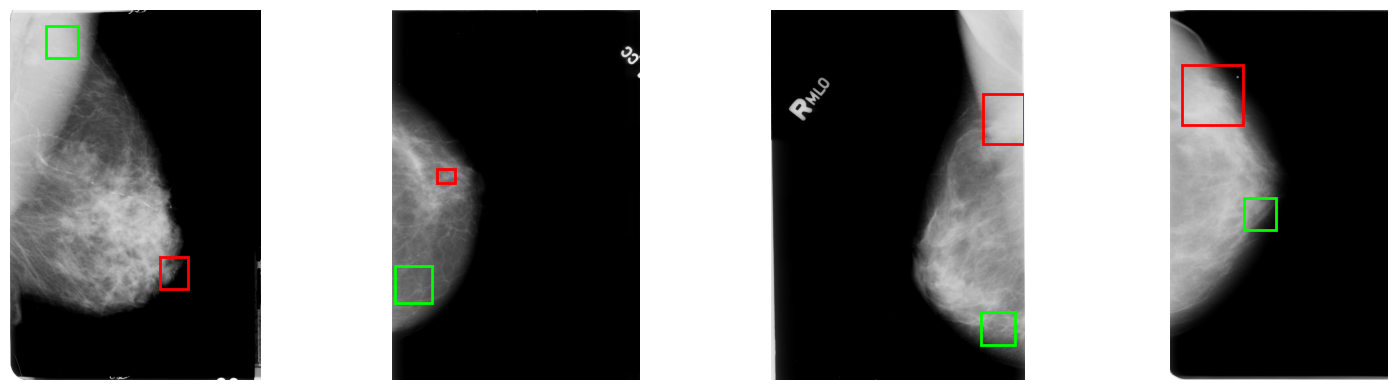

In [25]:
# Range informed by the real crop-size percentiles (25th-75th) found above
PATCH_SIZE_RANGE = (240, 480)

def load_mask_bbox(mask_path, target_size):
    # Load a mask, resize to target_size if needed, return the lesion's bounding box
    with Image.open(mask_path).convert('L') as m:
        if m.size != target_size:
            m = m.resize(target_size, Image.NEAREST)
        arr = np.array(m)
    ys, xs = np.where(arr > 10)  # small threshold to ignore JPEG compression noise
    if len(xs) == 0:
        return None
    return xs.min(), ys.min(), xs.max(), ys.max()

def boxes_overlap(a, b):
    ax0, ay0, ax1, ay1 = a
    bx0, by0, bx1, by1 = b
    return not (ax1 < bx0 or bx1 < ax0 or ay1 < by0 or by1 < ay0)

def has_sufficient_tissue(img_arr, box, min_tissue_fraction=0.6, intensity_threshold=15):
    # Reject boxes that are mostly black background rather than breast tissue
    x0, y0, x1, y1 = box
    patch = img_arr[y0:y1, x0:x1]
    tissue_fraction = (patch > intensity_threshold).mean()
    return tissue_fraction >= min_tissue_fraction

def sample_background_patch(img_arr, exclusion_boxes, patch_size_range, max_attempts=40):
    # Try to find a random square crop that avoids exclusion boxes AND lands on real tissue
    H, W = img_arr.shape
    for _ in range(max_attempts):
        size = random.randint(*patch_size_range)
        if size >= min(W, H):
            continue
        left = random.randint(0, W - size)
        top = random.randint(0, H - size)
        box = (left, top, left + size, top + size)
        if any(boxes_overlap(box, ex) for ex in exclusion_boxes):
            continue
        if not has_sufficient_tissue(img_arr, box):
            continue
        return box
    return None

# Visual test on 4 real mammograms
test_ids = full_manifest['study_uid'].sample(4, random_state=SEED).tolist()
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, sid in zip(axes, test_ids):
    row = full_manifest[full_manifest['study_uid'] == sid].iloc[0]
    with Image.open(row['image_path']) as img:
        img = img.convert('L')
        img_arr = np.array(img)
        H, W = img_arr.shape

        masks_for_this = mask_manifest[mask_manifest['parent_uid'] == sid]
        exclusion_boxes = [load_mask_bbox(m, (W, H)) for m in masks_for_this['mask_path']]
        exclusion_boxes = [b for b in exclusion_boxes if b is not None]

        bg_box = sample_background_patch(img_arr, exclusion_boxes, PATCH_SIZE_RANGE)

        ax.imshow(img_arr, cmap='gray')
        for (x0, y0, x1, y1) in exclusion_boxes:
            ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor='red', facecolor='none', linewidth=2))
        if bg_box:
            x0, y0, x1, y1 = bg_box
            ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor='lime', facecolor='none', linewidth=2))
        else:
            ax.set_title("FAILED to place", color='red')
        ax.axis('off')

plt.tight_layout()
plt.show()

Applies sample_background_patch to every mammogram to generate background patches, saving one 224x224 background patch per image to Drive. The code has been formatted out as text to prevent re-running.



```
NUM_BACKGROUND_PER_MAMMOGRAM = 1
PATCH_TARGET_SIZE = (224, 224)

BACKGROUND_DIR = ROOT / 'patches' / 'background'
BACKGROUND_DIR.mkdir(parents=True, exist_ok=True)

background_records = []
failed_count = 0

for _, row in tqdm(full_manifest.iterrows(), total=len(full_manifest)):
    sid = row['study_uid']
    masks_for_this = mask_manifest[mask_manifest['parent_uid'] == sid]

    with Image.open(row['image_path']) as img:
        img = img.convert('L')
        img_arr = np.array(img)
        H, W = img_arr.shape

        exclusion_boxes = [load_mask_bbox(m, (W, H)) for m in masks_for_this['mask_path']]
        exclusion_boxes = [b for b in exclusion_boxes if b is not None]

        for i in range(NUM_BACKGROUND_PER_MAMMOGRAM):
            out_path = BACKGROUND_DIR / f"{sid}_bg{i}.jpg"

            # skip if this patch was already generated in a prior run
            if out_path.exists():
                background_records.append({
                    'image_path': str(out_path),
                    'patch_class': 0,
                    'split': row['split'],
                })
                continue

            box = sample_background_patch(img_arr, exclusion_boxes, PATCH_SIZE_RANGE)
            if box is None:
                failed_count += 1
                continue

            x0, y0, x1, y1 = box
            patch = Image.fromarray(img_arr[y0:y1, x0:x1]).resize(PATCH_TARGET_SIZE, Image.LANCZOS)
            patch.save(out_path, quality=95)

            background_records.append({
                'image_path': str(out_path),
                'patch_class': 0,
                'split': row['split'],
            })

background_manifest = pd.DataFrame(background_records)
print(f"Background patches generated: {len(background_manifest)}")
print(f"Failed to place (skipped): {failed_count}")
print(background_manifest['split'].value_counts())
```



Merges the newly generated background patches with the existing cropped-image manifest. The cropped patches' binary label is combined with the background patches to create a 3-class patch manifest.



```
crop_manifest_3class = crop_manifest.copy()
crop_manifest_3class['patch_class'] = crop_manifest_3class['label'] + 1

patch_manifest = pd.concat([
    background_manifest[['image_path', 'patch_class', 'split']],
    crop_manifest_3class[['image_path', 'patch_class', 'split']],
], ignore_index=True)

print("Combined patch manifest rows:", len(patch_manifest))
print("\nClass counts by split:")
print(patch_manifest.groupby(['split', 'patch_class']).size().unstack())

patch_manifest.to_csv(MANIFEST_DIR / 'patch_manifest.csv', index=False)
print("Saved patch_manifest.csv")
```





```
crop_manifest_3class = crop_manifest.copy()
crop_manifest_3class['patch_class'] = crop_manifest_3class['label'] + 1

patch_manifest = pd.concat([
    background_manifest[['image_path', 'patch_class', 'split']],
    crop_manifest_3class[['image_path', 'patch_class', 'split']],
], ignore_index=True)

print("Combined patch manifest rows:", len(patch_manifest))
print("\nClass counts by split:")
print(patch_manifest.groupby(['split', 'patch_class']).size().unstack())

patch_manifest.to_csv(MANIFEST_DIR / 'patch_manifest.csv', index=False)
print("Saved patch_manifest.csv")
```



Reloads the saved patch manifest and verify files exist on Drive.

In [26]:
patch_manifest = pd.read_csv(MANIFEST_DIR / 'patch_manifest.csv')

print("Reloaded patch manifest rows:", len(patch_manifest))
print(patch_manifest.groupby(['split', 'patch_class']).size().unstack())

sample = patch_manifest['image_path'].sample(5)
for p in sample:
    print(Path(p).exists(), p)

Reloaded patch manifest rows: 6414
patch_class     0     1     2
split                        
test          399   428   276
train        2448  1682  1181
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.326707636811644902110897703793413722370/1-210.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.305908995513523110735329862673432425375/1-210.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/patches/background/Mass-Training_P_01687_RIGHT_CC_bg0.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/patches/background/Calc-Training_P_00196_RIGHT_MLO_bg0.jpg
True /content/drive/MyDrive/CBIS-DDSM-JPEG/jpeg/1.3.6.1.4.1.9590.100.1.2.298995667813572866526342340062137550931/1-200.jpg


Quick check on 5 samples in each class to confirm that background, benign, and malignant patches look distinct and correctly labelled.

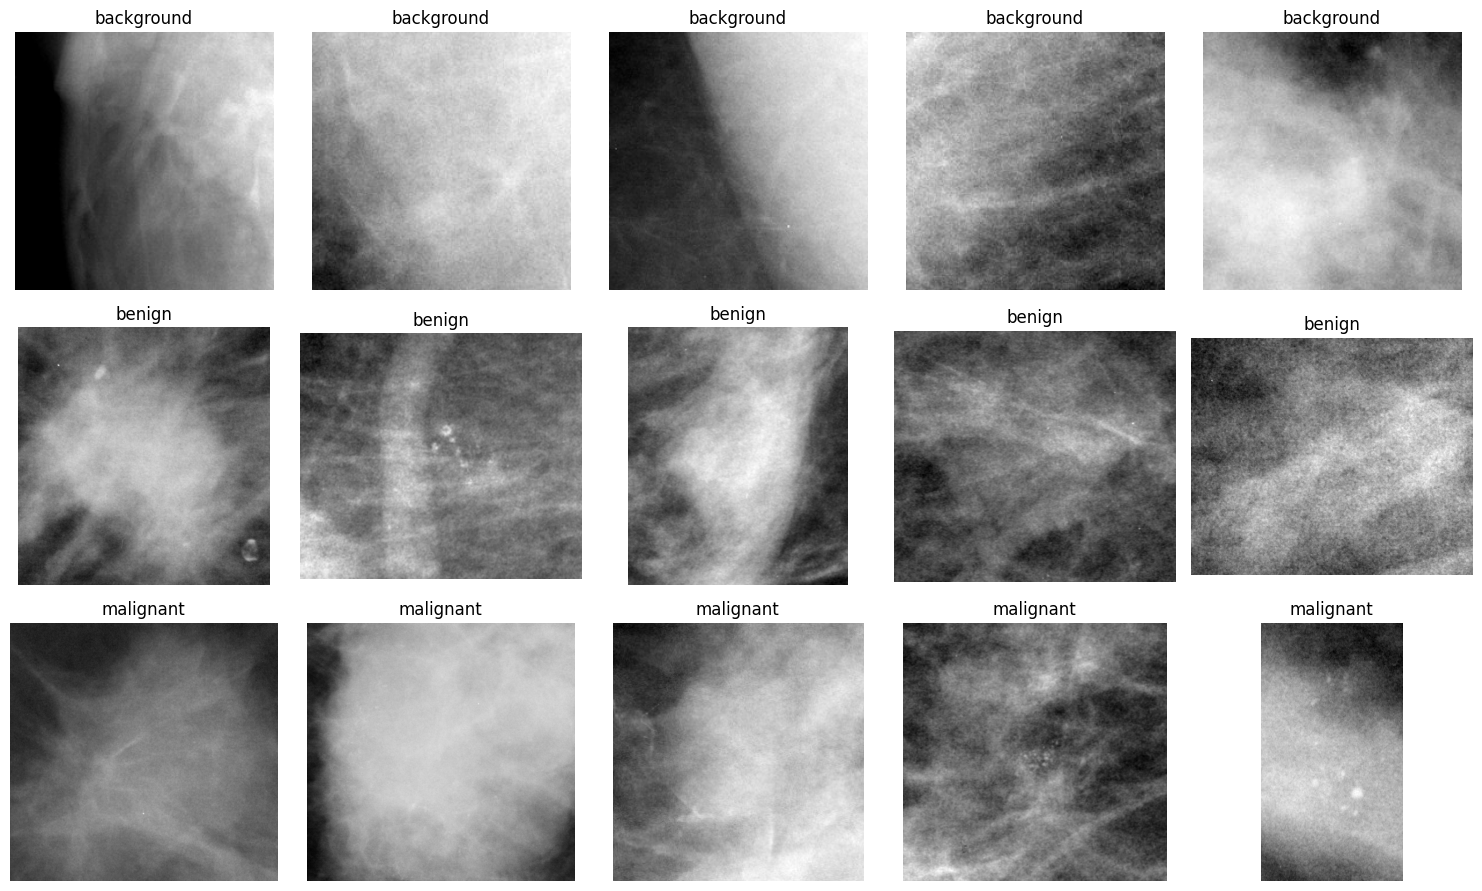

In [27]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
class_names = {0: 'background', 1: 'benign', 2: 'malignant'}

for row_idx, cls in enumerate([0, 1, 2]):
    samples = patch_manifest[patch_manifest['patch_class'] == cls].sample(5, random_state=SEED)
    for col_idx, (_, r) in enumerate(samples.iterrows()):
        with Image.open(r['image_path']) as img:
            axes[row_idx, col_idx].imshow(img.convert('L'), cmap='gray')
            axes[row_idx, col_idx].set_title(class_names[cls])
            axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.show()

## Patch Classifier Pipeline

The tf.data loading pipeline is created, with decode_patch reading and normalising each 224x224 JPEG patch, and make_patch_ds batching them into a tf.data pipeline.

In [28]:
IMG_SIZE = 224
AUTOTUNE = tf.data.AUTOTUNE

def decode_patch(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_patch_ds(sub, training=False):
    paths = sub['image_path'].values
    labels = sub['patch_class'].values.astype('int32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(sub), seed=SEED)
    ds = ds.map(decode_patch, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(32).prefetch(AUTOTUNE)
    return ds

patch_train_df = patch_manifest[patch_manifest.split == 'train'].reset_index(drop=True)
patch_test_df = patch_manifest[patch_manifest.split == 'test'].reset_index(drop=True)

patch_train_ds = make_patch_ds(patch_train_df, training=True)
patch_test_ds = make_patch_ds(patch_test_df)

# Verify one batch
for imgs, labels in patch_train_ds.take(1):
    print("Batch images:", imgs.shape, imgs.dtype)
    print("Pixel range:", float(imgs.numpy().min()), "-", float(imgs.numpy().max()))
    print("Batch labels:", labels.numpy()[:8])

Batch images: (32, 224, 224, 1) <dtype: 'float32'>
Pixel range: 0.0 - 0.998621940612793
Batch labels: [0 0 0 0 2 1 1 2]


Carves a validation set from the training pool using GroupShuffleSplit, grouped by the parent mammogram ID, so a lesion crop and its sibling background patch from the same mammogram cannot end up split across train and validation. The test set is left completely untouched.

In [29]:
crop_full = pd.read_csv(MANIFEST_DIR / 'cropped_patch_manifest.csv')

def get_parent_uid(row):
    if row['patch_class'] == 0:
        stem = Path(row['image_path']).stem
        return stem.rsplit('_bg', 1)[0]
    else:
        match = crop_full.loc[crop_full['image_path'] == row['image_path'], 'parent_uid']
        return match.iloc[0] if len(match) else None

patch_manifest['parent_uid'] = patch_manifest.apply(get_parent_uid, axis=1)
print("Rows missing parent_uid:", patch_manifest['parent_uid'].isna().sum())

train_pool = patch_manifest[patch_manifest.split == 'train'].reset_index(drop=True)
patch_test_df = patch_manifest[patch_manifest.split == 'test'].reset_index(drop=True)

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
train_idx, val_idx = next(gss.split(train_pool, groups=train_pool['parent_uid']))

patch_train_df = train_pool.iloc[train_idx].reset_index(drop=True)
patch_val_df = train_pool.iloc[val_idx].reset_index(drop=True)

overlap = set(patch_train_df['parent_uid']) & set(patch_val_df['parent_uid'])
print(f"Train: {len(patch_train_df)}  Val: {len(patch_val_df)}  Test: {len(patch_test_df)}")
print("Parent UID overlap between train/val (should be 0):", len(overlap))
print("\nTrain class balance:", patch_train_df['patch_class'].value_counts(normalize=True).to_dict())
print("Val class balance:", patch_val_df['patch_class'].value_counts(normalize=True).to_dict())
print("Test class balance:", patch_test_df['patch_class'].value_counts(normalize=True).to_dict())

Rows missing parent_uid: 0
Train: 4792  Val: 519  Test: 1103
Parent UID overlap between train/val (should be 0): 0

Train class balance: {0: 0.4595158597662771, 1: 0.31803005008347246, 2: 0.22245409015025042}
Val class balance: {0: 0.47398843930635837, 1: 0.3044315992292871, 2: 0.22157996146435452}
Test class balance: {1: 0.38803263825929285, 0: 0.3617407071622847, 2: 0.25022665457842247}


The final tf.dataset is built by applying the corrected 3-way split to produce the actual datasets used for model training from this point onward.

In [30]:
patch_train_ds = make_patch_ds(patch_train_df, training=True)
patch_val_ds = make_patch_ds(patch_val_df)
patch_test_ds = make_patch_ds(patch_test_df)

## Patch Classifier (Baseline)

The deep learning models were implemented according to Chollet's Deep Learning Workflow steps. A baseline CNN is defined and compiled first.

In [31]:
model_baseline = models.Sequential([
    layers.Input((IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(16, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax'),
])

model_baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,651 (108.01 KB)

 Trainable params: 27,651 (108.01 KB)

 Non-trainable params: 0 (0.00 B)

Since the 3 classes are imbalanced, compute_class_weight is implemented to produces weights so training penalises minority-class errors more. The majority-class validation accuracy is also computed and will be the number the trained baseline model needs to beat.

In [32]:
classes = np.array([0, 1, 2])
weights = compute_class_weight('balanced', classes=classes, y=patch_train_df['patch_class'].values)
class_weight = {0: weights[0], 1: weights[1], 2: weights[2]}
print("class_weight:", class_weight)

# Baseline majority-class accuracy
majority_class = patch_train_df['patch_class'].mode()[0]
baseline_val_acc = (patch_val_df['patch_class'] == majority_class).mean()
print(f"Majority class: {majority_class} ({class_names[majority_class]})")
print(f"Baseline val accuracy: {baseline_val_acc:.4f}")

class_weight: {0: np.float64(0.7254011504692703), 1: np.float64(1.048118985126859), 2: np.float64(1.4984365228267666)}
Majority class: 0 (background)
Baseline val accuracy: 0.4740


The baseline model is trained for up to 30 epochs with early stopping on validation loss, restoring the best-performing epoch's weights.

In [33]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_baseline = model_baseline.fit(
    patch_train_ds,
    validation_data=patch_val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=[early_stop],
)

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.3990 - loss: 1.0646 - val_accuracy: 0.4836 - val_loss: 1.0554
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6206 - loss: 0.8413 - val_accuracy: 0.6012 - val_loss: 0.9315
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7026 - loss: 0.6544 - val_accuracy: 0.5896 - val_loss: 0.9805
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7181 - loss: 0.6131 - val_accuracy: 0.6570 - val_loss: 0.6193
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7310 - loss: 0.5703 - val_accuracy: 0.7341 - val_loss: 0.4910
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7429 - loss: 0.5651 - val_accuracy: 0.7110 - val_loss: 0.4973
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7519 - loss: 0.5312 - val_accuracy: 0.7476 - val_loss: 0.4877
Epoch 8/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7479 - loss: 0.5491 - val_accu

The baseline's results are plotted to confirm the final validation accuracy against the majority-class baseline and visualise loss/accuracy over training to check for stable convergence.

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7399 - loss: 0.4613

Final val accuracy: 0.7399  (baseline: 0.4740)


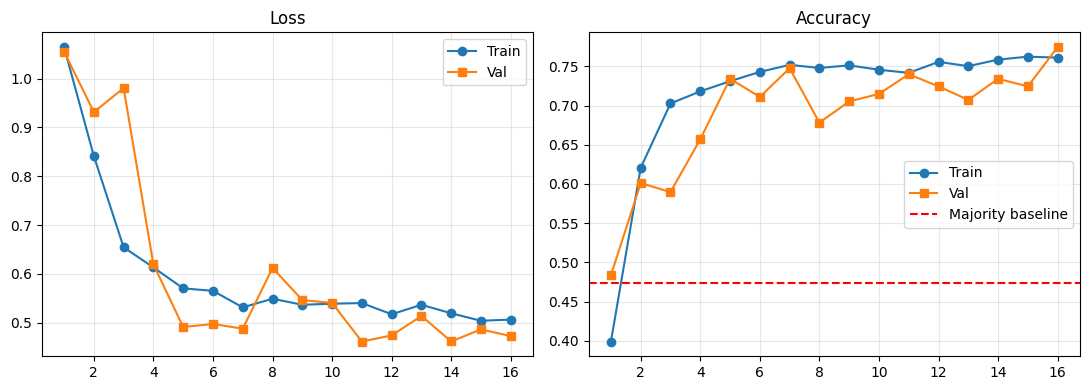

In [34]:
val_loss, val_acc = model_baseline.evaluate(patch_val_ds)
print(f"\nFinal val accuracy: {val_acc:.4f}  (baseline: {baseline_val_acc:.4f})")

epochs_range = range(1, len(history_baseline.history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs_range, history_baseline.history['loss'], 'o-', label='Train')
axes[0].plot(epochs_range, history_baseline.history['val_loss'], 's-', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_range, history_baseline.history['accuracy'], 'o-', label='Train')
axes[1].plot(epochs_range, history_baseline.history['val_accuracy'], 's-', label='Val')
axes[1].axhline(baseline_val_acc, color='red', ls='--', label='Majority baseline')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Patch Classifier (Expanded Capacity)

The next step requires forcibly overfitting the model to confirm that it has representational capacity. The baseline model is extended to 5 conv blocks to cause the model to overfit.

In [35]:
model_capacity = models.Sequential([
    layers.Input((IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(32, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(256, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(512, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dense(3, activation='softmax'),
])

model_capacity.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model_capacity.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,832,195 (6.99 MB)

 Trainable params: 1,832,195 (6.99 MB)

 Non-trainable params: 0 (0.00 B)

The expanded model is deliberately trained on the full 30 epochs without early stopping so any emerging overfitting is visible rather than cut short.

In [36]:
history_capacity = model_capacity.fit(
    patch_train_ds,
    validation_data=patch_val_ds,
    epochs=30,
    class_weight=class_weight,
)

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 26s 109ms/step - accuracy: 0.4432 - loss: 1.0340 - val_accuracy: 0.5723 - val_loss: 0.8182
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.6642 - loss: 0.7174 - val_accuracy: 0.6435 - val_loss: 0.5891
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7233 - loss: 0.5919 - val_accuracy: 0.6956 - val_loss: 0.5365
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7450 - loss: 0.5324 - val_accuracy: 0.7688 - val_loss: 0.4297
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7446 - loss: 0.5046 - val_accuracy: 0.7418 - val_loss: 0.5051
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7454 - loss: 0.5241 - val_accuracy: 0.7168 - val_loss: 0.4669
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7552 - loss: 0.4950 - val_accuracy: 0.7514 - val_loss: 0.4388
Epoch 8/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7577 - loss: 0.4996 - val_ac

The model's results are plotted to verify overfitting has occured by checking for a widening gap between training and validation accuracy/loss.

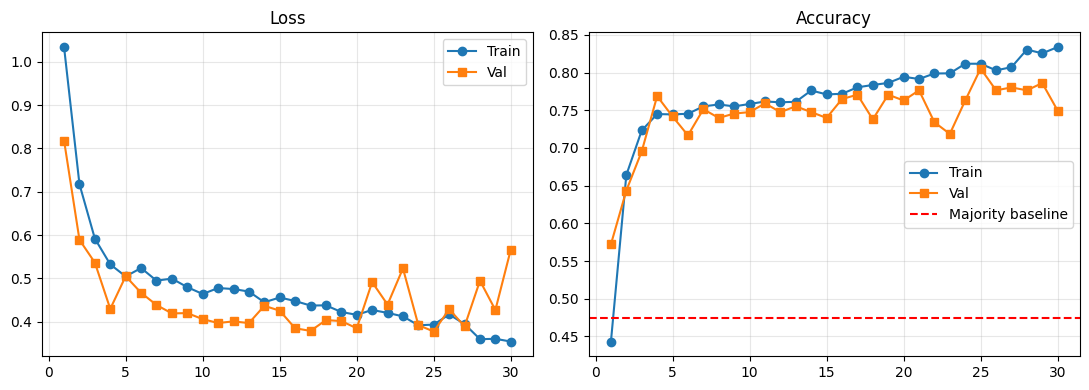

Final train accuracy: 0.8339
Final val accuracy:   0.7495


In [37]:
epochs_range = range(1, len(history_capacity.history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs_range, history_capacity.history['loss'], 'o-', label='Train')
axes[0].plot(epochs_range, history_capacity.history['val_loss'], 's-', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_capacity.history['accuracy'], 'o-', label='Train')
axes[1].plot(epochs_range, history_capacity.history['val_accuracy'], 's-', label='Val')
axes[1].axhline(baseline_val_acc, color='red', ls='--', label='Majority baseline')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

final_train_acc = history_capacity.history['accuracy'][-1]
final_val_acc = history_capacity.history['val_accuracy'][-1]
print(f"Final train accuracy: {final_train_acc:.4f}")
print(f"Final val accuracy:   {final_val_acc:.4f}")

## Patch Classifier (Regularised Model)

Adds data augmentation (horizontal flip, small rotation, small zoom) and a dropout layer as regularisation method to close the overfitting gap observed in the expanded capacity model. This is the model whose convolutional backbone will also gets reused in the whole-image classifier.

In [38]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),   # ~15 degrees max
    layers.RandomZoom(0.1),
], name="patch_augmentation")

model_patch_final = models.Sequential([
    layers.Input((IMG_SIZE, IMG_SIZE, 1)),
    data_augmentation,
    layers.Conv2D(32, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(256, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(512, 3, padding='same', activation='relu'), layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax'),
], name='patch_classifier')  # named + kept as a distinct object

model_patch_final.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model_patch_final.summary()

Model: "patch_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ patch_augmentation (Sequential) │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,832,195 (6.99 MB)

 Trainable params: 1,832,195 (6.99 MB)

 Non-trainable params: 0 (0.00 B)

The regularised model is trained for up to 30 epochs with early stopping on validation loss, restoring the best-performing epoch's weights.

In [39]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True
)

history_patch_final = model_patch_final.fit(
    patch_train_ds,
    validation_data=patch_val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=[early_stop],
)

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.4743 - loss: 1.0214 - val_accuracy: 0.6513 - val_loss: 0.6676
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6665 - loss: 0.7531 - val_accuracy: 0.6358 - val_loss: 0.6474
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7091 - loss: 0.6426 - val_accuracy: 0.6763 - val_loss: 0.6575
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7412 - loss: 0.5486 - val_accuracy: 0.7322 - val_loss: 0.4657
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.7454 - loss: 0.5269 - val_accuracy: 0.7264 - val_loss: 0.4336
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7531 - loss: 0.5077 - val_accuracy: 0.7225 - val_loss: 0.4685
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7446 - loss: 0.5242 - val_accuracy: 0.7495 - val_loss: 0.4309
Epoch 8/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7477 - loss: 0.5133 - val_acc

The regularised model's resutls are plotted to confirm that the overfitting gap had closed.

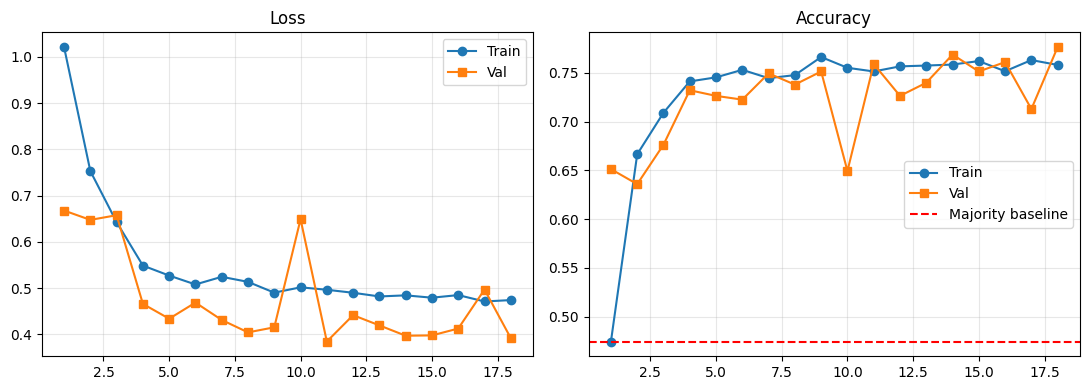

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7592 - loss: 0.3842
Restored-weights val accuracy: 0.7592  (val loss: 0.3842)


In [40]:
epochs_range = range(1, len(history_patch_final.history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs_range, history_patch_final.history['loss'], 'o-', label='Train')
axes[0].plot(epochs_range, history_patch_final.history['val_loss'], 's-', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_patch_final.history['accuracy'], 'o-', label='Train')
axes[1].plot(epochs_range, history_patch_final.history['val_accuracy'], 's-', label='Val')
axes[1].axhline(baseline_val_acc, color='red', ls='--', label='Majority baseline')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

val_loss, val_acc = model_patch_final.evaluate(patch_val_ds)
print(f"Restored-weights val accuracy: {val_acc:.4f}  (val loss: {val_loss:.4f})")

## Backbone Layer

The trained convolutional backbone is extracted from the trained patch classifier, with the weights frozen so that they can be reused in the whole-image classifier model.

In [41]:
backbone_layers = [
    layer for layer in model_patch_final.layers
    if isinstance(layer, (layers.Conv2D, layers.MaxPooling2D))
]

print(f"Extracted {len(backbone_layers)} backbone layers:")
for l in backbone_layers:
    print(" -", l.name, l.__class__.__name__, "trainable:", l.trainable)

for layer in backbone_layers:
    layer.trainable = False

Extracted 10 backbone layers:
 - conv2d_8 Conv2D trainable: True
 - max_pooling2d_8 MaxPooling2D trainable: True
 - conv2d_9 Conv2D trainable: True
 - max_pooling2d_9 MaxPooling2D trainable: True
 - conv2d_10 Conv2D trainable: True
 - max_pooling2d_10 MaxPooling2D trainable: True
 - conv2d_11 Conv2D trainable: True
 - max_pooling2d_11 MaxPooling2D trainable: True
 - conv2d_12 Conv2D trainable: True
 - max_pooling2d_12 MaxPooling2D trainable: True


## Whole-image Classifier (Frozen Baseline)

The whole-image model is built using the frozen backbone, with new convolutional layers and a dense head added on top. Only these new top layers are trainable at this stage.

In [42]:
IMG_SIZE_FULL = 512

whole_input = layers.Input((IMG_SIZE_FULL, IMG_SIZE_FULL, 1), name='whole_image_input')
x = whole_input
for layer in backbone_layers:
    x = layer(x)

x = layers.Conv2D(512, 3, padding='same', activation='relu', name='top_conv1')(x)
x = layers.MaxPooling2D(name='top_pool1')(x)
x = layers.Conv2D(512, 3, padding='same', activation='relu', name='top_conv2')(x)
x = layers.GlobalAveragePooling2D(name='top_gap')(x)
x = layers.Dense(128, activation='relu', name='top_dense')(x)
x = layers.Dropout(0.3, name='top_dropout')(x)
output = layers.Dense(1, activation='sigmoid', name='whole_image_output')(x)

model_whole = models.Model(inputs=whole_input, outputs=output, name='whole_image_classifier')
model_whole.summary()  # check trainable vs non-trainable param split

Model: "whole_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ whole_image_input (InputLayer)  │ (None, 512, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 512, 512, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_conv1 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_pool1 (MaxPooling2D)        │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_conv2 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_gap                         │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dense (Dense)               │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ whole_image_output (Dense)      │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,353,409 (24.24 MB)

 Trainable params: 4,785,409 (18.25 MB)

 Non-trainable params: 1,568,000 (5.98 MB)

The official CBIS-DDSM test set is left untouched, and a new validation set is carved from the training pool using GroupShuffleSplit (grouped by patient_id) to prevent the same patient's images to leak across training and validation sets.

In [43]:
patient_lookup = cases[['study_uid', 'patient_id']].drop_duplicates()
full_manifest = full_manifest.merge(patient_lookup, on='study_uid', how='left')
print("Rows missing patient_id:", full_manifest['patient_id'].isna().sum())

full_train_pool = full_manifest[full_manifest.split == 'train'].reset_index(drop=True)
full_test_df = full_manifest[full_manifest.split == 'test'].reset_index(drop=True)  # official split, untouched

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
train_idx, val_idx = next(gss.split(full_train_pool, groups=full_train_pool['patient_id']))

full_train_df = full_train_pool.iloc[train_idx].reset_index(drop=True)
full_val_df = full_train_pool.iloc[val_idx].reset_index(drop=True)

overlap = set(full_train_df['patient_id']) & set(full_val_df['patient_id'])
print(f"Train: {len(full_train_df)}  Val: {len(full_val_df)}  Test: {len(full_test_df)}")
print("Patient overlap between train/val (should be 0):", len(overlap))
print("\nTrain label balance:", full_train_df['label'].mean())
print("Val label balance:", full_val_df['label'].mean())

Rows missing patient_id: 0
Train: 2204  Val: 254  Test: 399
Patient overlap between train/val (should be 0): 0

Train label balance: 0.45054446460980035
Val label balance: 0.43700787401574803


Builds the tf.data pipeline for full mammograms. Each image is decoded at 512x512 resolution, with pixel values normalised, and batches at a smaller size (16, vs. 32 for patches) since full images require more GPU memory per batch.

In [44]:
def decode_full(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, [IMG_SIZE_FULL, IMG_SIZE_FULL])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_full_ds(sub, training=False):
    paths = sub['image_path'].values
    labels = sub['label'].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(sub), seed=SEED)
    ds = ds.map(decode_full, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(16).prefetch(AUTOTUNE)  # smaller batch than patches - 512x512 through a 5-block backbone uses far more memory
    return ds

full_train_ds = make_full_ds(full_train_df, training=True)
full_val_ds = make_full_ds(full_val_df)
full_test_ds = make_full_ds(full_test_df)

for imgs, batch_labels in full_train_ds.take(1):
    print("Batch images:", imgs.shape, imgs.dtype)
    print("Pixel range:", float(imgs.numpy().min()), "-", float(imgs.numpy().max()))
    print("Batch labels:", batch_labels.numpy()[:8])

Batch images: (16, 512, 512, 1) <dtype: 'float32'>
Pixel range: 0.0 - 1.0
Batch labels: [0. 0. 0. 1. 0. 0. 1. 1.]


The frozen backbone model is compiled with class weights computed to correct for the imbalance between benign and malignant cases. The model uses binary cross-entropy loss and tracks AUC alongisde accuracy.

In [45]:
model_whole.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
)

weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=full_train_df['label'].values)
class_weight_full = {0: weights[0], 1: weights[1]}

majority_class_full = full_train_df['label'].mode()[0]
baseline_val_acc_full = (full_val_df['label'] == majority_class_full).mean()
print(f"class_weight: {class_weight_full}")
print(f"Majority class: {majority_class_full}  Baseline val accuracy: {baseline_val_acc_full:.4f}")

class_weight: {0: np.float64(0.9099917423616846), 1: np.float64(1.1097683786505539)}
Majority class: 0  Baseline val accuracy: 0.5630


The frozen backbone model is trained for up to 30 epochs with early stopping. As mentioned earlier, only the new top layers learn at this stage and the transferred backbone stays fixed. This establishes whether the patch-learned features are useful at all for full-image classification before any fine-tuning is attempted.

In [46]:
early_stop_frozen = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_frozen = model_whole.fit(
    full_train_ds,
    validation_data=full_val_ds,
    epochs=30,
    class_weight=class_weight_full,
    callbacks=[early_stop_frozen],
)

Epoch 1/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.5413 - auc: 0.5555 - loss: 0.6948 - val_accuracy: 0.5945 - val_auc: 0.6119 - val_loss: 0.6699
Epoch 2/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.5903 - auc: 0.6258 - loss: 0.6697 - val_accuracy: 0.5945 - val_auc: 0.6565 - val_loss: 0.6720
Epoch 3/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.6189 - auc: 0.6509 - loss: 0.6604 - val_accuracy: 0.6378 - val_auc: 0.6840 - val_loss: 0.6522
Epoch 4/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.6252 - auc: 0.6585 - loss: 0.6529 - val_accuracy: 0.6102 - val_auc: 0.6592 - val_loss: 0.6542
Epoch 5/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.6198 - auc: 0.6729 - loss: 0.6437 - val_accuracy: 0.6024 - val_auc: 0.6611 - val_loss: 0.6424
Epoch 6/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 108ms/step - accuracy: 0.6257 - auc: 0.6815 - loss: 0.6382 - val_accuracy: 0.5906 - val_auc: 0.6793 - val_loss: 0.6392
Epoch 7/30
138/138 ━━━━━

The model's results are plotted and evaluted, with validation accuracy and AUC reported against the majority baseline and chance level (0.5).

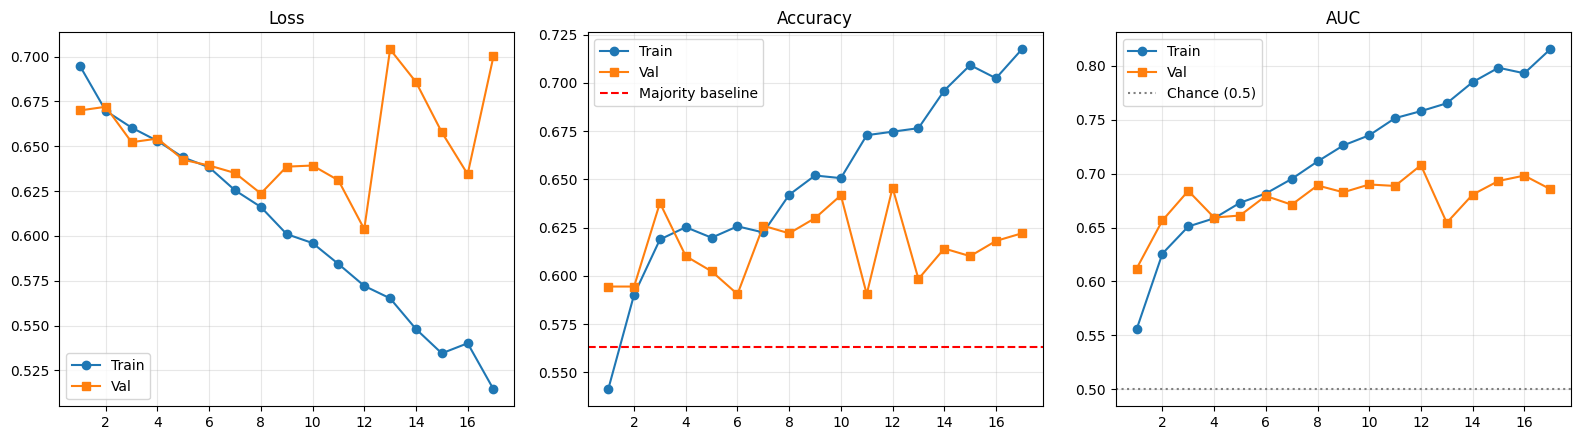

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.6457 - auc: 0.7077 - loss: 0.6038

Restored-weights val accuracy: 0.6457  (baseline: 0.5630)
Restored-weights val AUC: 0.7077


In [47]:
epochs_range = range(1, len(history_frozen.history['loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(epochs_range, history_frozen.history['loss'], 'o-', label='Train')
axes[0].plot(epochs_range, history_frozen.history['val_loss'], 's-', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_frozen.history['accuracy'], 'o-', label='Train')
axes[1].plot(epochs_range, history_frozen.history['val_accuracy'], 's-', label='Val')
axes[1].axhline(baseline_val_acc_full, color='red', ls='--', label='Majority baseline')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history_frozen.history['auc'], 'o-', label='Train')
axes[2].plot(epochs_range, history_frozen.history['val_auc'], 's-', label='Val')
axes[2].axhline(0.5, color='gray', ls=':', label='Chance (0.5)')
axes[2].set_title('AUC'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

val_loss, val_acc, val_auc = model_whole.evaluate(full_val_ds)
print(f"\nRestored-weights val accuracy: {val_acc:.4f}  (baseline: {baseline_val_acc_full:.4f})")
print(f"Restored-weights val AUC: {val_auc:.4f}")

## Whole-image Classifier (Fine-tuning stage)

The model is rebuilt with augmentation added and the backbone unfrozen. The same style of augmentation from patch classifier was added here for regularisation. The backbone was also unfrozen to allow the weights to update, though at a much smaller learning rate than default so that the pretained weight will still only shift gently instead of being fully overwritten and updated.

In [48]:
data_augmentation_full = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.1),
], name="whole_image_augmentation")

whole_input = layers.Input((IMG_SIZE_FULL, IMG_SIZE_FULL, 1), name='whole_image_input')
x = data_augmentation_full(whole_input)
for layer in backbone_layers:
    x = layer(x)

x = layers.Conv2D(512, 3, padding='same', activation='relu', name='top_conv1')(x)
x = layers.MaxPooling2D(name='top_pool1')(x)
x = layers.Conv2D(512, 3, padding='same', activation='relu', name='top_conv2')(x)
x = layers.GlobalAveragePooling2D(name='top_gap')(x)
x = layers.Dense(128, activation='relu', name='top_dense')(x)
x = layers.Dropout(0.3, name='top_dropout')(x)
output = layers.Dense(1, activation='sigmoid', name='whole_image_output')(x)

model_whole = models.Model(inputs=whole_input, outputs=output, name='whole_image_classifier')

for layer in backbone_layers:
    layer.trainable = True

model_whole.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
)
model_whole.summary()

Model: "whole_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ whole_image_input (InputLayer)  │ (None, 512, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ whole_image_augmentation        │ (None, 512, 512, 1)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 512, 512, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_conv1 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_pool1 (MaxPooling2D)        │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_conv2 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_gap                         │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dense (Dense)               │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ whole_image_output (Dense)      │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,353,409 (24.24 MB)

 Trainable params: 6,353,409 (24.24 MB)

 Non-trainable params: 0 (0.00 B)

The fine-tuned model is trained for up to 30 epochs with early stopping.

In [49]:
early_stop_finetune = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)

history_finetune = model_whole.fit(
    full_train_ds,
    validation_data=full_val_ds,
    epochs=30,
    class_weight=class_weight_full,
    callbacks=[early_stop_finetune],
)

Epoch 1/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step - accuracy: 0.5454 - auc: 0.5488 - loss: 0.6899 - val_accuracy: 0.4488 - val_auc: 0.6469 - val_loss: 0.6946
Epoch 2/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.5490 - auc: 0.5732 - loss: 0.6869 - val_accuracy: 0.6220 - val_auc: 0.6457 - val_loss: 0.6794
Epoch 3/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.5771 - auc: 0.6000 - loss: 0.6806 - val_accuracy: 0.5906 - val_auc: 0.6491 - val_loss: 0.6807
Epoch 4/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - accuracy: 0.5953 - auc: 0.6142 - loss: 0.6762 - val_accuracy: 0.5984 - val_auc: 0.6348 - val_loss: 0.6675
Epoch 5/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.5876 - auc: 0.6294 - loss: 0.6681 - val_accuracy: 0.6220 - val_auc: 0.6505 - val_loss: 0.6714
Epoch 6/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.6021 - auc: 0.6285 - loss: 0.6689 - val_accuracy: 0.6142 - val_auc: 0.6511 - val_loss: 0.6738
Epoch 7/30
138/138 ━━━

The fine-tuned model's results are plotted and evaluated to compare the validation AUC against the frozen-stage baseline results.

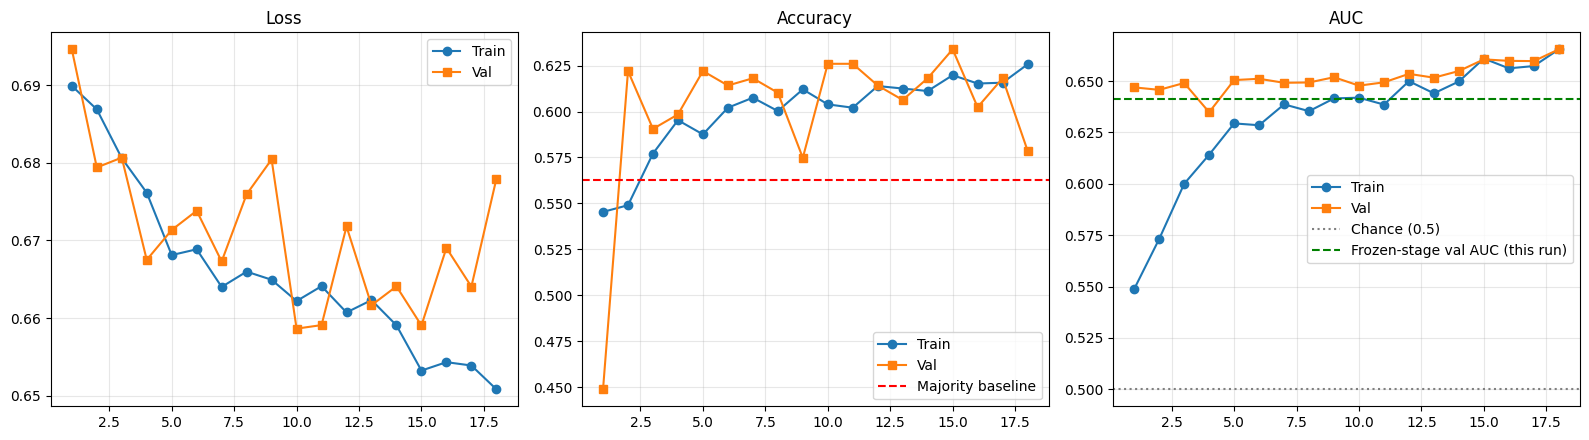

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.6260 - auc: 0.6478 - loss: 0.6586

Restored-weights val accuracy: 0.6260
Restored-weights val AUC: 0.6478  (frozen-stage baseline: 0.6411)


In [50]:
epochs_range = range(1, len(history_finetune.history['loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(epochs_range, history_finetune.history['loss'], 'o-', label='Train')
axes[0].plot(epochs_range, history_finetune.history['val_loss'], 's-', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_finetune.history['accuracy'], 'o-', label='Train')
axes[1].plot(epochs_range, history_finetune.history['val_accuracy'], 's-', label='Val')
axes[1].axhline(baseline_val_acc_full, color='red', ls='--', label='Majority baseline')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history_finetune.history['auc'], 'o-', label='Train')
axes[2].plot(epochs_range, history_finetune.history['val_auc'], 's-', label='Val')
axes[2].axhline(0.5, color='gray', ls=':', label='Chance (0.5)')
axes[2].axhline(0.6411, color='green', ls='--', label='Frozen-stage val AUC (this run)')
axes[2].set_title('AUC'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

val_loss_ft, val_acc_ft, val_auc_ft = model_whole.evaluate(full_val_ds)
print(f"\nRestored-weights val accuracy: {val_acc_ft:.4f}")
print(f"Restored-weights val AUC: {val_auc_ft:.4f}  (frozen-stage baseline: 0.6411)")

## Hyperparameter Tuning

The trained backbone's weights are captured to reuse across tuning trials, ensuring that each trial starts from the identical trained backbone layer.

In [51]:
BACKBONE_FILTERS = [32, 64, 128, 256, 512]

backbone_weights_snapshot = [
    layer.get_weights()
    for layer in model_patch_final.layers
    if isinstance(layer, layers.Conv2D)
]
print(f"Captured weights for {len(backbone_weights_snapshot)} Conv2D layers")

Captured weights for 5 Conv2D layers


The hypermodel for KerasTuner is defined, with unfreeze_blocks and learning_rate as the main searched parameters for the hyperparameter tuning step.

In [52]:
def build_model(hp):
    unfreeze_n = hp.Choice('unfreeze_blocks', [1, 2, 5])
    lr = hp.Choice('learning_rate', [1e-4, 1e-5, 5e-6])
    dropout_rate = 0.3

    fresh_backbone_layers = []
    for i, n_filters in enumerate(BACKBONE_FILTERS):
        conv = layers.Conv2D(n_filters, 3, padding='same', activation='relu', name=f'tuner_conv{i}')
        pool = layers.MaxPooling2D(name=f'tuner_pool{i}')
        fresh_backbone_layers.append(conv)
        fresh_backbone_layers.append(pool)

    blocks = [fresh_backbone_layers[i:i+2] for i in range(0, len(fresh_backbone_layers), 2)]
    for layer in fresh_backbone_layers:
        layer.trainable = False
    for block in blocks[-unfreeze_n:]:
        for layer in block:
            layer.trainable = True

    whole_input = layers.Input((IMG_SIZE_FULL, IMG_SIZE_FULL, 1))
    x = data_augmentation_full(whole_input)
    for layer in fresh_backbone_layers:
        x = layer(x)
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=whole_input, outputs=output)

    conv_layers_in_model = [l for l in fresh_backbone_layers if isinstance(l, layers.Conv2D)]
    for layer, weights in zip(conv_layers_in_model, backbone_weights_snapshot):
        layer.set_weights(weights)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model

Runs the grid search which trains and evaluates all 9 combinations of unfreeze depth (1/2/5 blocks) and learning rate (1e-4/1e-5/5e-6), and then selecting the best by validation AUC.

In [53]:
tuner = kt.GridSearch(
    build_model,
    objective=kt.Objective('val_auc', direction='max'),
    executions_per_trial=1,
    directory=str(ROOT / 'tuner'),
    project_name='whole_image_unfreeze_lr',
    overwrite=True,
    seed=SEED,
)

tuner.search(
    full_train_ds,
    validation_data=full_val_ds,
    epochs=25,
    class_weight=class_weight_full,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)],
)

Trial 9 Complete [00h 04m 36s]
val_auc: 0.6615321040153503

Best val_auc So Far: 0.6993007063865662
Total elapsed time: 00h 47m 27s


Reviews the grid search results by listing all 9 trials by validation AUC to identify the best-performing hyperparameter combination.

In [54]:
tuner.results_summary(num_trials=9)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest config:", best_hp.values)

best_model = tuner.get_best_models(num_models=1)[0]
val_loss, val_acc, val_auc = best_model.evaluate(full_val_ds)
print(f"Best model val AUC: {val_auc:.4f}  (current non-tuned result: 0.6587)")

Results summary
Results in /content/drive/MyDrive/CBIS-DDSM-JPEG/tuner/whole_image_unfreeze_lr
Showing 9 best trials
Objective(name="val_auc", direction="max")

Trial 0000 summary
Hyperparameters:
unfreeze_blocks: 1
learning_rate: 0.0001
Score: 0.6993007063865662

Trial 0003 summary
Hyperparameters:
unfreeze_blocks: 2
learning_rate: 0.0001
Score: 0.684590220451355

Trial 0007 summary
Hyperparameters:
unfreeze_blocks: 5
learning_rate: 1e-05
Score: 0.683613657951355

Trial 0006 summary
Hyperparameters:
unfreeze_blocks: 5
learning_rate: 0.0001
Score: 0.6817237138748169

Trial 0004 summary
Hyperparameters:
unfreeze_blocks: 2
learning_rate: 1e-05
Score: 0.6661941409111023

Trial 0008 summary
Hyperparameters:
unfreeze_blocks: 5
learning_rate: 5e-06
Score: 0.6615321040153503

Trial 0005 summary
Hyperparameters:
unfreeze_blocks: 2
learning_rate: 5e-06
Score: 0.6581301093101501

Trial 0001 summary
Hyperparameters:
unfreeze_blocks: 1
learning_rate: 1e-05
Score: 0.657720685005188

Trial 0002 summ

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.5551 - auc: 0.6993 - loss: 0.6559 
Best model val AUC: 0.6993  (current non-tuned result: 0.6587)


## Final Model
The model was retrained from scratch cleanly using the winning hyperparameters found (unfreeze 5 blocks and learning rate of 1e-4).

In [55]:
def build_model_with_hp(unfreeze_n, lr, dropout_rate=0.3):
    fresh_backbone_layers = []
    for i, n_filters in enumerate(BACKBONE_FILTERS):
        conv = layers.Conv2D(n_filters, 3, padding='same', activation='relu', name=f'final_conv{i}')
        pool = layers.MaxPooling2D(name=f'final_pool{i}')
        fresh_backbone_layers.append(conv)
        fresh_backbone_layers.append(pool)

    blocks = [fresh_backbone_layers[i:i+2] for i in range(0, len(fresh_backbone_layers), 2)]
    for layer in fresh_backbone_layers:
        layer.trainable = False
    for block in blocks[-unfreeze_n:]:
        for layer in block:
            layer.trainable = True

    whole_input = layers.Input((IMG_SIZE_FULL, IMG_SIZE_FULL, 1))
    x = data_augmentation_full(whole_input)
    for layer in fresh_backbone_layers:
        x = layer(x)
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=whole_input, outputs=output)
    conv_layers_in_model = [l for l in fresh_backbone_layers if isinstance(l, layers.Conv2D)]
    for layer, weights in zip(conv_layers_in_model, backbone_weights_snapshot):
        layer.set_weights(weights)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model

final_model = build_model_with_hp(unfreeze_n=5, lr=1e-4)

early_stop_final = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history_final = final_model.fit(
    full_train_ds, validation_data=full_val_ds,
    epochs=30, class_weight=class_weight_full,
    callbacks=[early_stop_final],
)

val_loss, val_acc, val_auc = final_model.evaluate(full_val_ds)
print(f"Clean retrain val AUC: {val_auc:.4f}  (tuner-reported: 0.6794)")

MODEL_DIR = ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)
final_model.save(MODEL_DIR / 'whole_image_final.keras')

Epoch 1/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.5422 - auc: 0.5589 - loss: 0.6888 - val_accuracy: 0.5630 - val_auc: 0.6115 - val_loss: 0.6805
Epoch 2/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.5794 - auc: 0.6114 - loss: 0.6748 - val_accuracy: 0.5984 - val_auc: 0.6268 - val_loss: 0.6793
Epoch 3/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.5953 - auc: 0.6221 - loss: 0.6713 - val_accuracy: 0.5906 - val_auc: 0.6294 - val_loss: 0.6690
Epoch 4/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 110ms/step - accuracy: 0.5839 - auc: 0.6186 - loss: 0.6715 - val_accuracy: 0.5866 - val_auc: 0.6334 - val_loss: 0.6729
Epoch 5/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - accuracy: 0.5985 - auc: 0.6435 - loss: 0.6607 - val_accuracy: 0.6181 - val_auc: 0.6390 - val_loss: 0.6581
Epoch 6/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - accuracy: 0.6057 - auc: 0.6428 - loss: 0.6609 - val_accuracy: 0.5472 - val_auc: 0.6556 - val_loss: 0.6808
Epoch 7/30
138/138 ━━━

### Evalution on Held-Out Test Set

The final model is ran on the held-out test set, and the sensitivity, specificity and AUC is reported alongside a confusion matrix.

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step
Sensitivity (malignant recall): 0.640
Specificity (benign recall):    0.532
AUC:                             0.647
Accuracy:                       0.576  (baseline: 0.589)


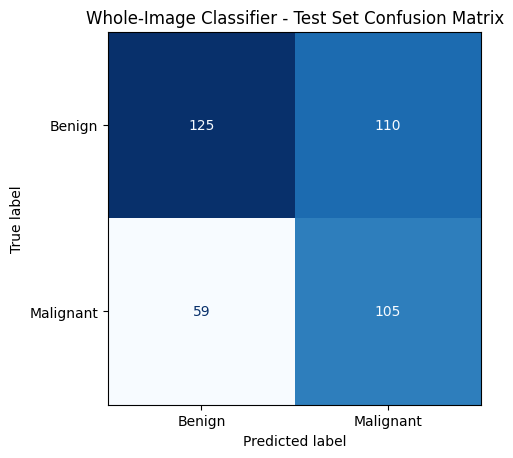

In [56]:
y_true = np.concatenate([y.numpy() for _, y in full_test_ds])
y_prob = final_model.predict(full_test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
auc = roc_auc_score(y_true, y_prob)

test_baseline_acc = (y_true == np.bincount(full_train_df['label']).argmax()).mean()

print(f"Sensitivity (malignant recall): {sensitivity:.3f}")
print(f"Specificity (benign recall):    {specificity:.3f}")
print(f"AUC:                             {auc:.3f}")
print(f"Accuracy:                       {(tp+tn)/(tp+tn+fp+fn):.3f}  (baseline: {test_baseline_acc:.3f})")

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Whole-Image Classifier - Test Set Confusion Matrix')
plt.tight_layout()
plt.show()